In [8]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames

In [9]:
using Revise
using Newtrinos
using Newtrinos.osc

In [10]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}(NND(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 100.0, r = 1.0, η = 1.01), (m₀ = LogUniform{Float64}(a=1.0e-6, b=0.1), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = DiscreteUniform(a=2, b=40), r = Uniform{Float64}(a=1.0e-8, b=1.0), η = Uniform{Float64}(a=1.01, b=100.0)), Newtrinos.osc.var"#get_Nnaturalness#54"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig

In [11]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [12]:
experiments = (

  dayabay= Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [13]:
p = Newtrinos.get_params(experiments)

(N = 100.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [14]:
using Setfield

In [15]:
# modify the value of m0 with a random value taken from a Distribution

sigma= 2*p.m₀/10
new_m₀_un = rand(Uniform(p.m₀, p.m₀*sqrt(3))) 
new_m₀_norm= rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*sqrt(3)))
p_new_un = @set p.m₀ = new_m₀_un
p_new_norm = @set p.m₀ = new_m₀_norm


(N = 100.0, m₀ = 0.01009558261541578, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [16]:
assets= experiments.dayabay.assets

(E_arrs = [[1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43]], L_arrs = [[1919.63, 1917.52, 1925.26, 1894.34, 1891.98, 1899.86, 1533.18, 1534.92, 1538.93, 1533.63, 1535.03, 1539.47, 1551.38, 1554.77, 1556.34, 1524.94, 1528.05, 1530.08], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18]], Npred_EH3_nooscs = [[966.99789101819, 1311.4889551891888, 1854.178347329635, 2317.3210980

In [17]:
expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))


26-element Vector{Float64}:
 59297.89790953825
 62052.7103861568
 56968.270056543246
 70140.98942768057
 78213.66788407591
 87144.95967355091
 87830.77738998781
 83117.7849513581
 78877.8461711084
 73589.88563134427
 66482.75354507251
 60141.82161351402
 54124.09447330283
 49260.65886371598
 44874.26388780374
 40041.37393029999
 33700.88309321056
 34690.078094455224
 25436.030932117348
 19937.53335161061
 14747.288228698799
  9929.277442858489
  6445.669847797011
  6779.115835924664
  3712.388433057122
 17342.675780321893

In [18]:
expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))


26-element Vector{Float64}:
 59304.79024857539
 62049.37029316378
 56973.35653455787
 70152.34621103591
 78218.51133433146
 87151.11872940273
 87836.46464423153
 83115.80847831926
 78884.96846186543
 73592.97352056322
 66483.37819257853
 60148.10655411819
 54125.079089479754
 49263.931292046596
 44879.58680245499
 40043.94686085108
 33701.32291027842
 34696.8376995001
 25439.072783755106
 19939.64999894042
 14749.625438953597
  9930.536477824393
  6446.231502998797
  6779.016365567052
  3712.7821745207752
 17343.978497272463

In [19]:
using CairoMakie

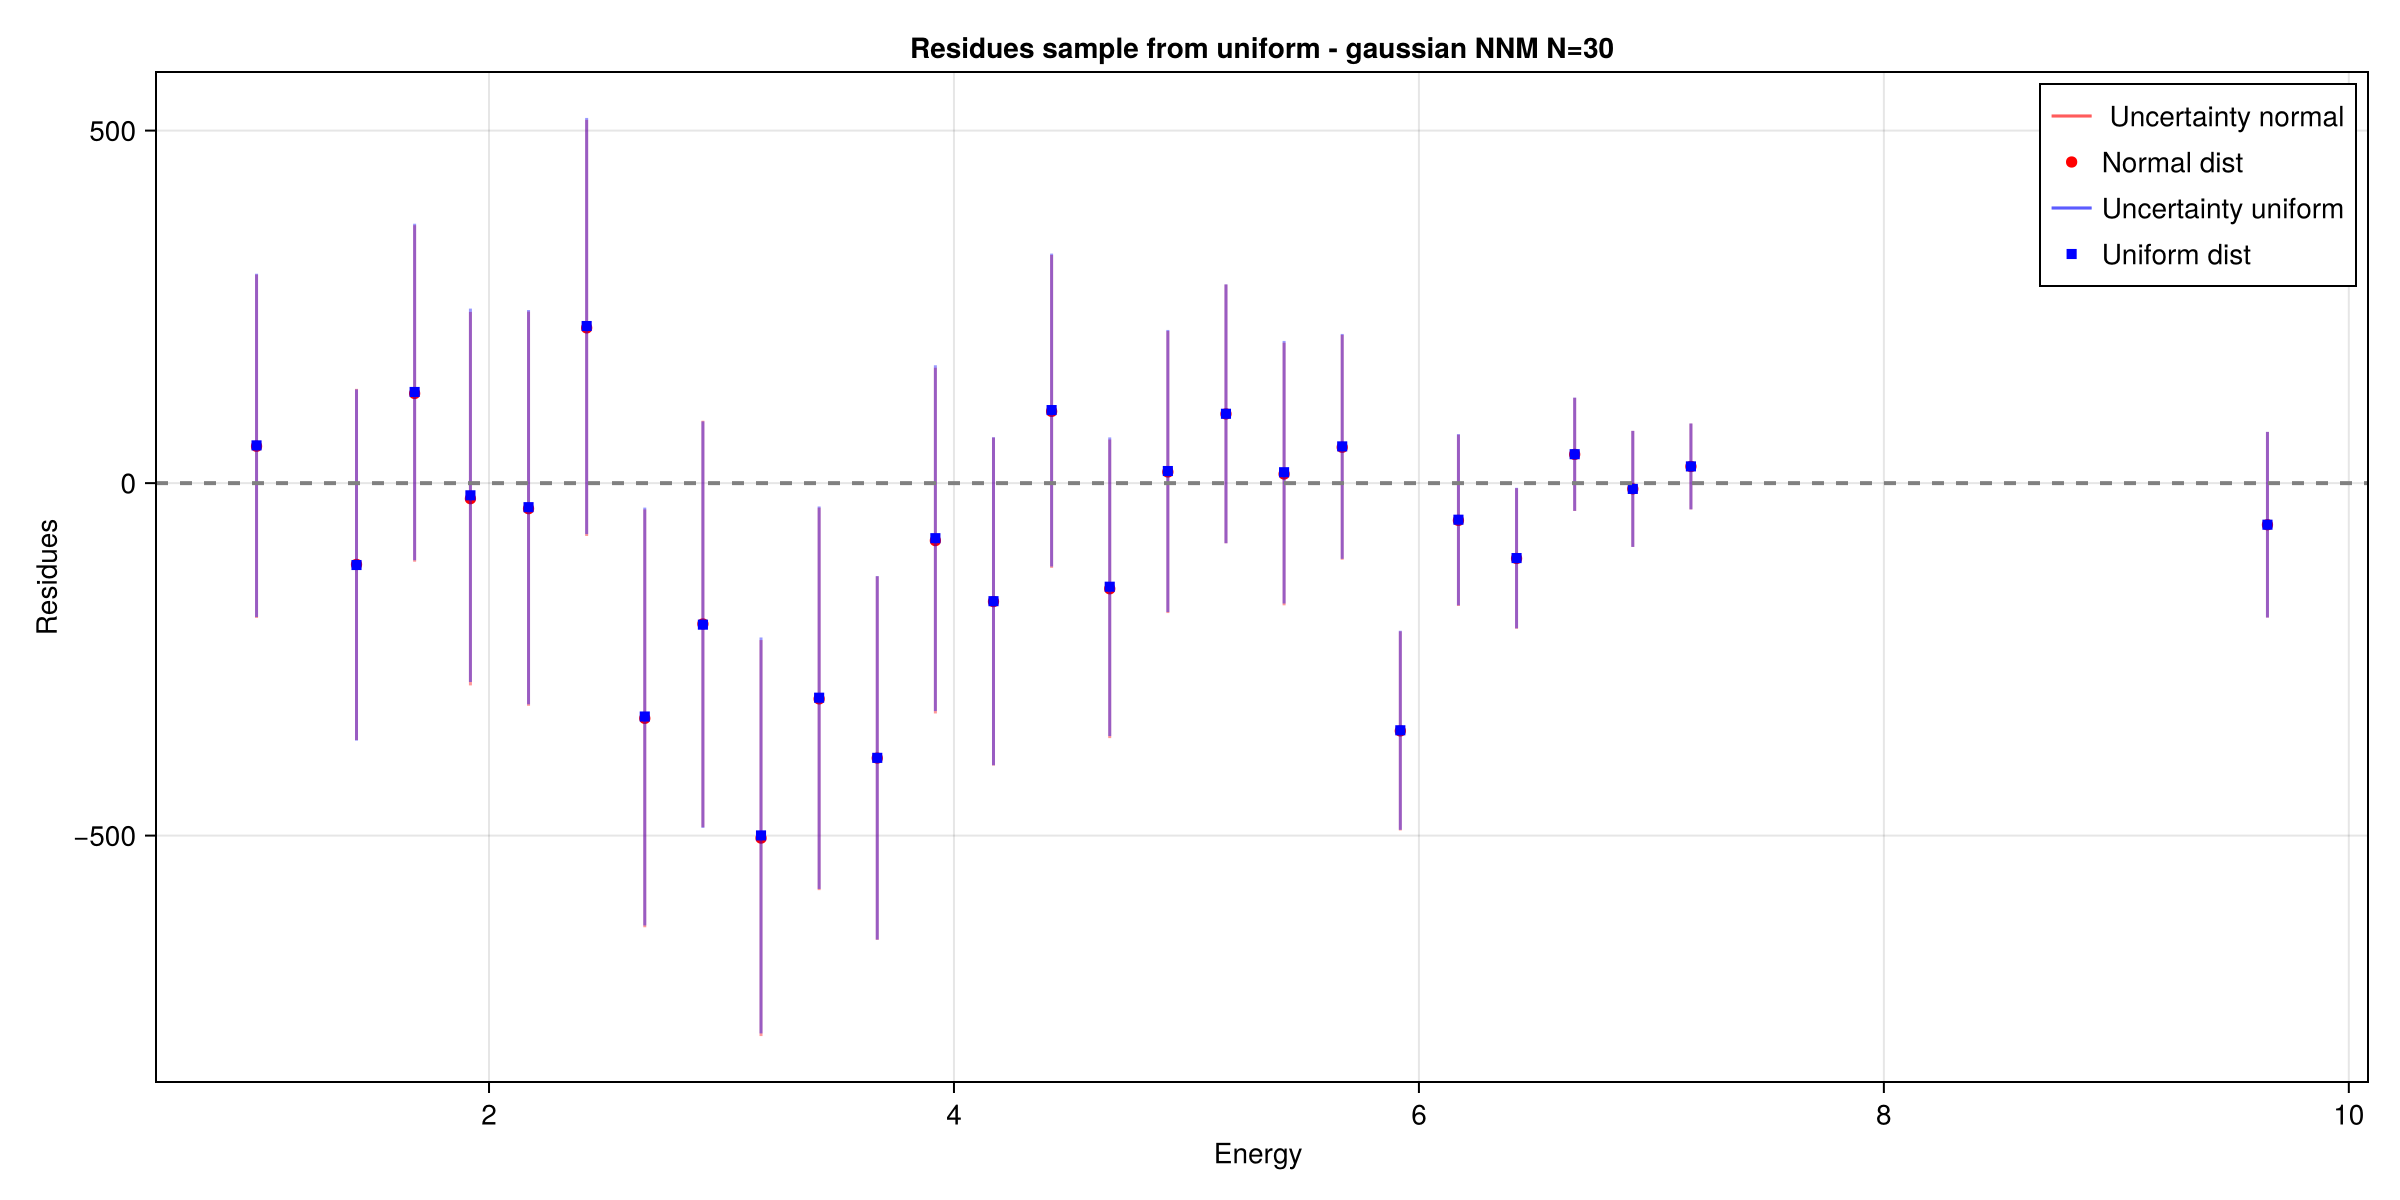

CairoMakie.Screen{IMAGE}


In [20]:

# Create the figure
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "Energy ",
    ylabel = "Residues", 
    title = "Residues sample from uniform - gaussian NNM N=30")


errorbars!(ax, assets.energy,  assets.observed-expected_norm,  sqrt.(expected_norm_var), 
      color = (:red, 0.4), label = " Uncertainty normal")

scatter!(ax, assets.energy,  assets.observed-expected_norm, 
        color = :red, markersize = 8, label = "Normal dist")

errorbars!(ax, assets.energy,  assets.observed-expected_un,sqrt.(expected_un_var), 
      color = (:blue, 0.4), label = "Uncertainty uniform")
      
scatter!(ax, assets.energy, assets.observed-expected_un, 
        color = :blue, marker = :rect, markersize = 8,label = "Uniform dist")

        
# Add a horizontal line at zero for reference
hlines!(ax, [0], color = :gray, linestyle = :dash, linewidth = 2)

    
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/dayabay/nm_dayabay_NNM_N30_residues.png", fig)

In [21]:
#img = experiments.dayabay.plot(p_new_norm)
#display("image/png", img)

In [22]:

using ProgressMeter
using MeasureBase

In [23]:
function random_sampling(physics, experiments, p, N)

   chi_squared_un_list = Float64[]
   chi_squared_norm_list = Float64[]

   @showprogress for i in 1:100
      #println("Random sampling iteration: $i")
      sigma=2*p.m₀/1000
      new_m₀_un = rand(Uniform(p.m₀, p.m₀*sqrt(3)))
      new_m₀_norm= rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*sqrt(3)))
      p_new_un = @set p.m₀ = new_m₀_un
      p_new_norm = @set p.m₀ =new_m₀_norm
      #p_new_un = @set p.N = N
      #p_new_norm = @set p.N = N


      assets= experiments.dayabay.assets
      observed = assets.observed

      expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
      expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))

    
      likelihood_norm=logdensityof(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm), observed)
      likelihood_un=logdensityof(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un), observed)

      push!(chi_squared_un_list, likelihood_un)
      push!(chi_squared_norm_list, likelihood_norm)

   end
   return chi_squared_un_list, chi_squared_norm_list
end

random_sampling (generic function with 1 method)

In [24]:
trial=random_sampling(physics, experiments, p, 25)

Progress: 100%|█████████████████████████████████████████| Time: 2:59:29


([-168.62537499904494, -168.56875037500834, -168.64120264131935, -168.64506467070663, -168.6241196481203, -168.619066978546, -168.61572380083516, -168.62238169218978, -168.5900296783971, -168.6221582994645  …  -168.62585138294875, -168.6188276318947, -168.62259371237857, -168.59883113009482, -168.61462533291754, -168.6538970803145, -168.62222525619484, -168.62471313097296, -168.6191832693663, -168.65194767968495], [-168.6280001268972, -168.63533685915363, -168.63123060405007, -168.64838895374658, -168.6284990393645, -168.62467553806255, -168.5944331604263, -168.62969093853928, -168.63885358490484, -168.64707857239313  …  -168.6433288470896, -168.63227953935004, -168.6228536442514, -168.58998611856987, -168.6381004304232, -168.6180495409247, -168.65350070759018, -168.59752758394507, -168.62808601157025, -168.6522528152955])

In [25]:
trial=.-trial # to have the negative log likelihood

([168.62537499904494, 168.56875037500834, 168.64120264131935, 168.64506467070663, 168.6241196481203, 168.619066978546, 168.61572380083516, 168.62238169218978, 168.5900296783971, 168.6221582994645  …  168.62585138294875, 168.6188276318947, 168.62259371237857, 168.59883113009482, 168.61462533291754, 168.6538970803145, 168.62222525619484, 168.62471313097296, 168.6191832693663, 168.65194767968495], [168.6280001268972, 168.63533685915363, 168.63123060405007, 168.64838895374658, 168.6284990393645, 168.62467553806255, 168.5944331604263, 168.62969093853928, 168.63885358490484, 168.64707857239313  …  168.6433288470896, 168.63227953935004, 168.6228536442514, 168.58998611856987, 168.6381004304232, 168.6180495409247, 168.65350070759018, 168.59752758394507, 168.62808601157025, 168.6522528152955])

In [26]:
mean_un=mean(trial[1])
mean_norm=mean(trial[2])

168.63094120144072

In [27]:
# standard model for comparison
osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc= Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc, atm_flux, earth_layers);

experiments_SM = (

  dayabay= Newtrinos.dayabay.configure(physics_SM),
);

p_SM = Newtrinos.get_params(experiments_SM)

likelihood_SM=-logdensityof(Newtrinos.dayabay.get_forward_model(physics_SM, assets)(p_SM), assets.observed)

[ Info: Loading dayabay data


168.90003273508322

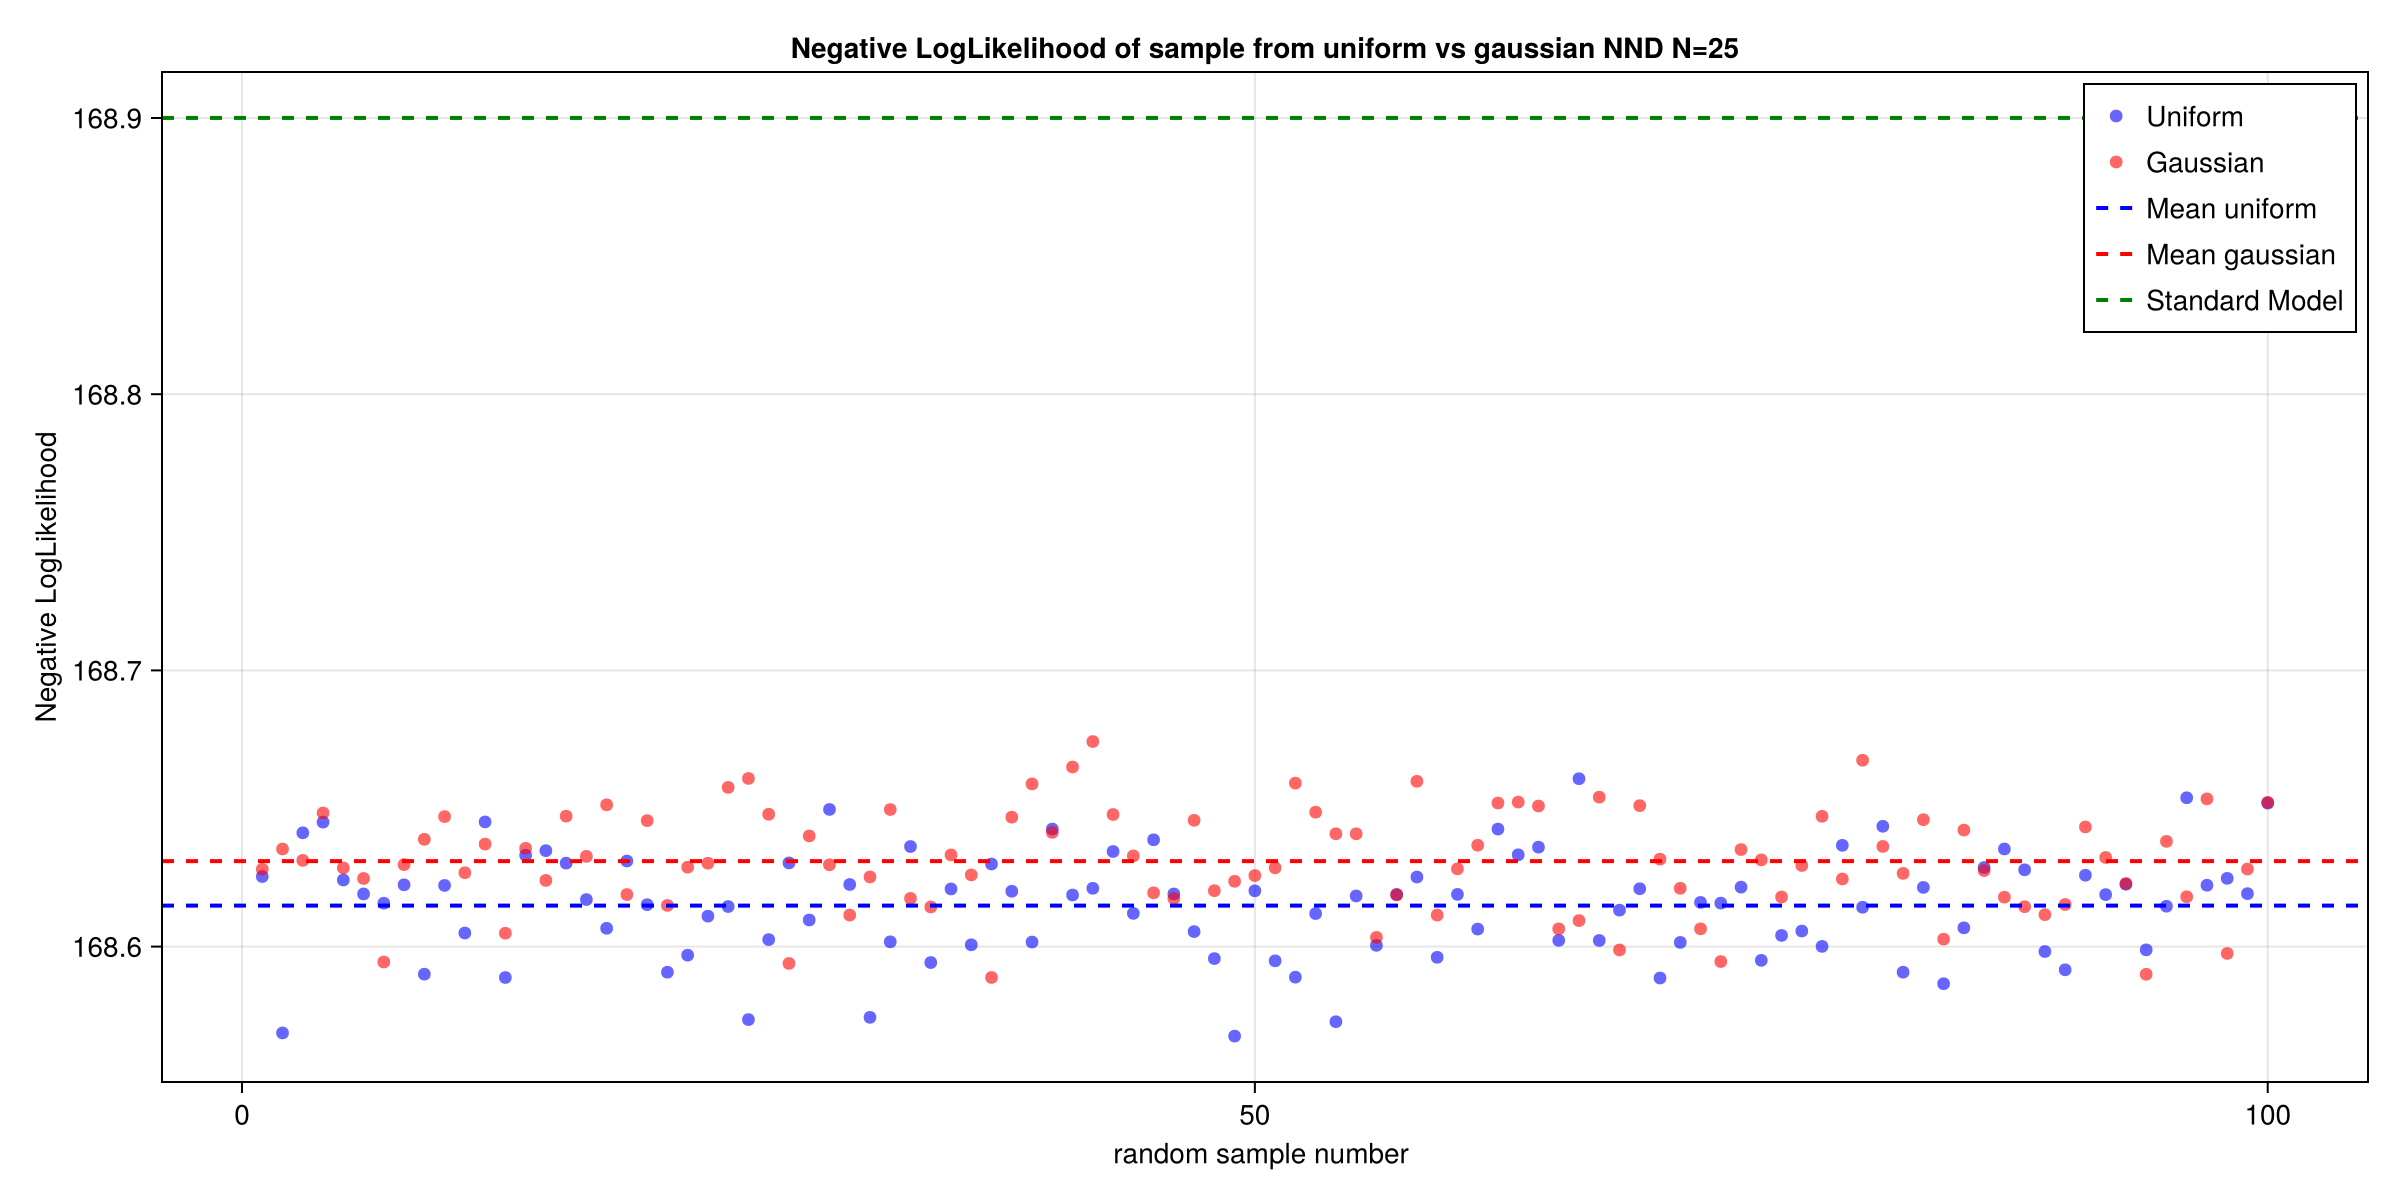

CairoMakie.Screen{IMAGE}


In [28]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "random sample number ",
    ylabel = "Negative LogLikelihood", 
    title = "Negative LogLikelihood of sample from uniform vs gaussian NND N=25")
scatter!(ax, 1:100, trial[1], color = (:blue, 0.6), label = "Uniform")
scatter!(ax, 1:100, trial[2], color = (:red, 0.6), label = "Gaussian")


hlines!(ax, [mean_un], color = :blue, linestyle = :dash, linewidth = 2, label = "Mean uniform")
hlines!(ax, [mean_norm], color = :red, linestyle = :dash, linewidth = 2, label = "Mean gaussian")
hlines!(ax, likelihood_SM, color = :green, linestyle = :dash, linewidth = 2, label = "Standard Model")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/dayabay_samples_NNM_N20_m0=0.1.png", fig)

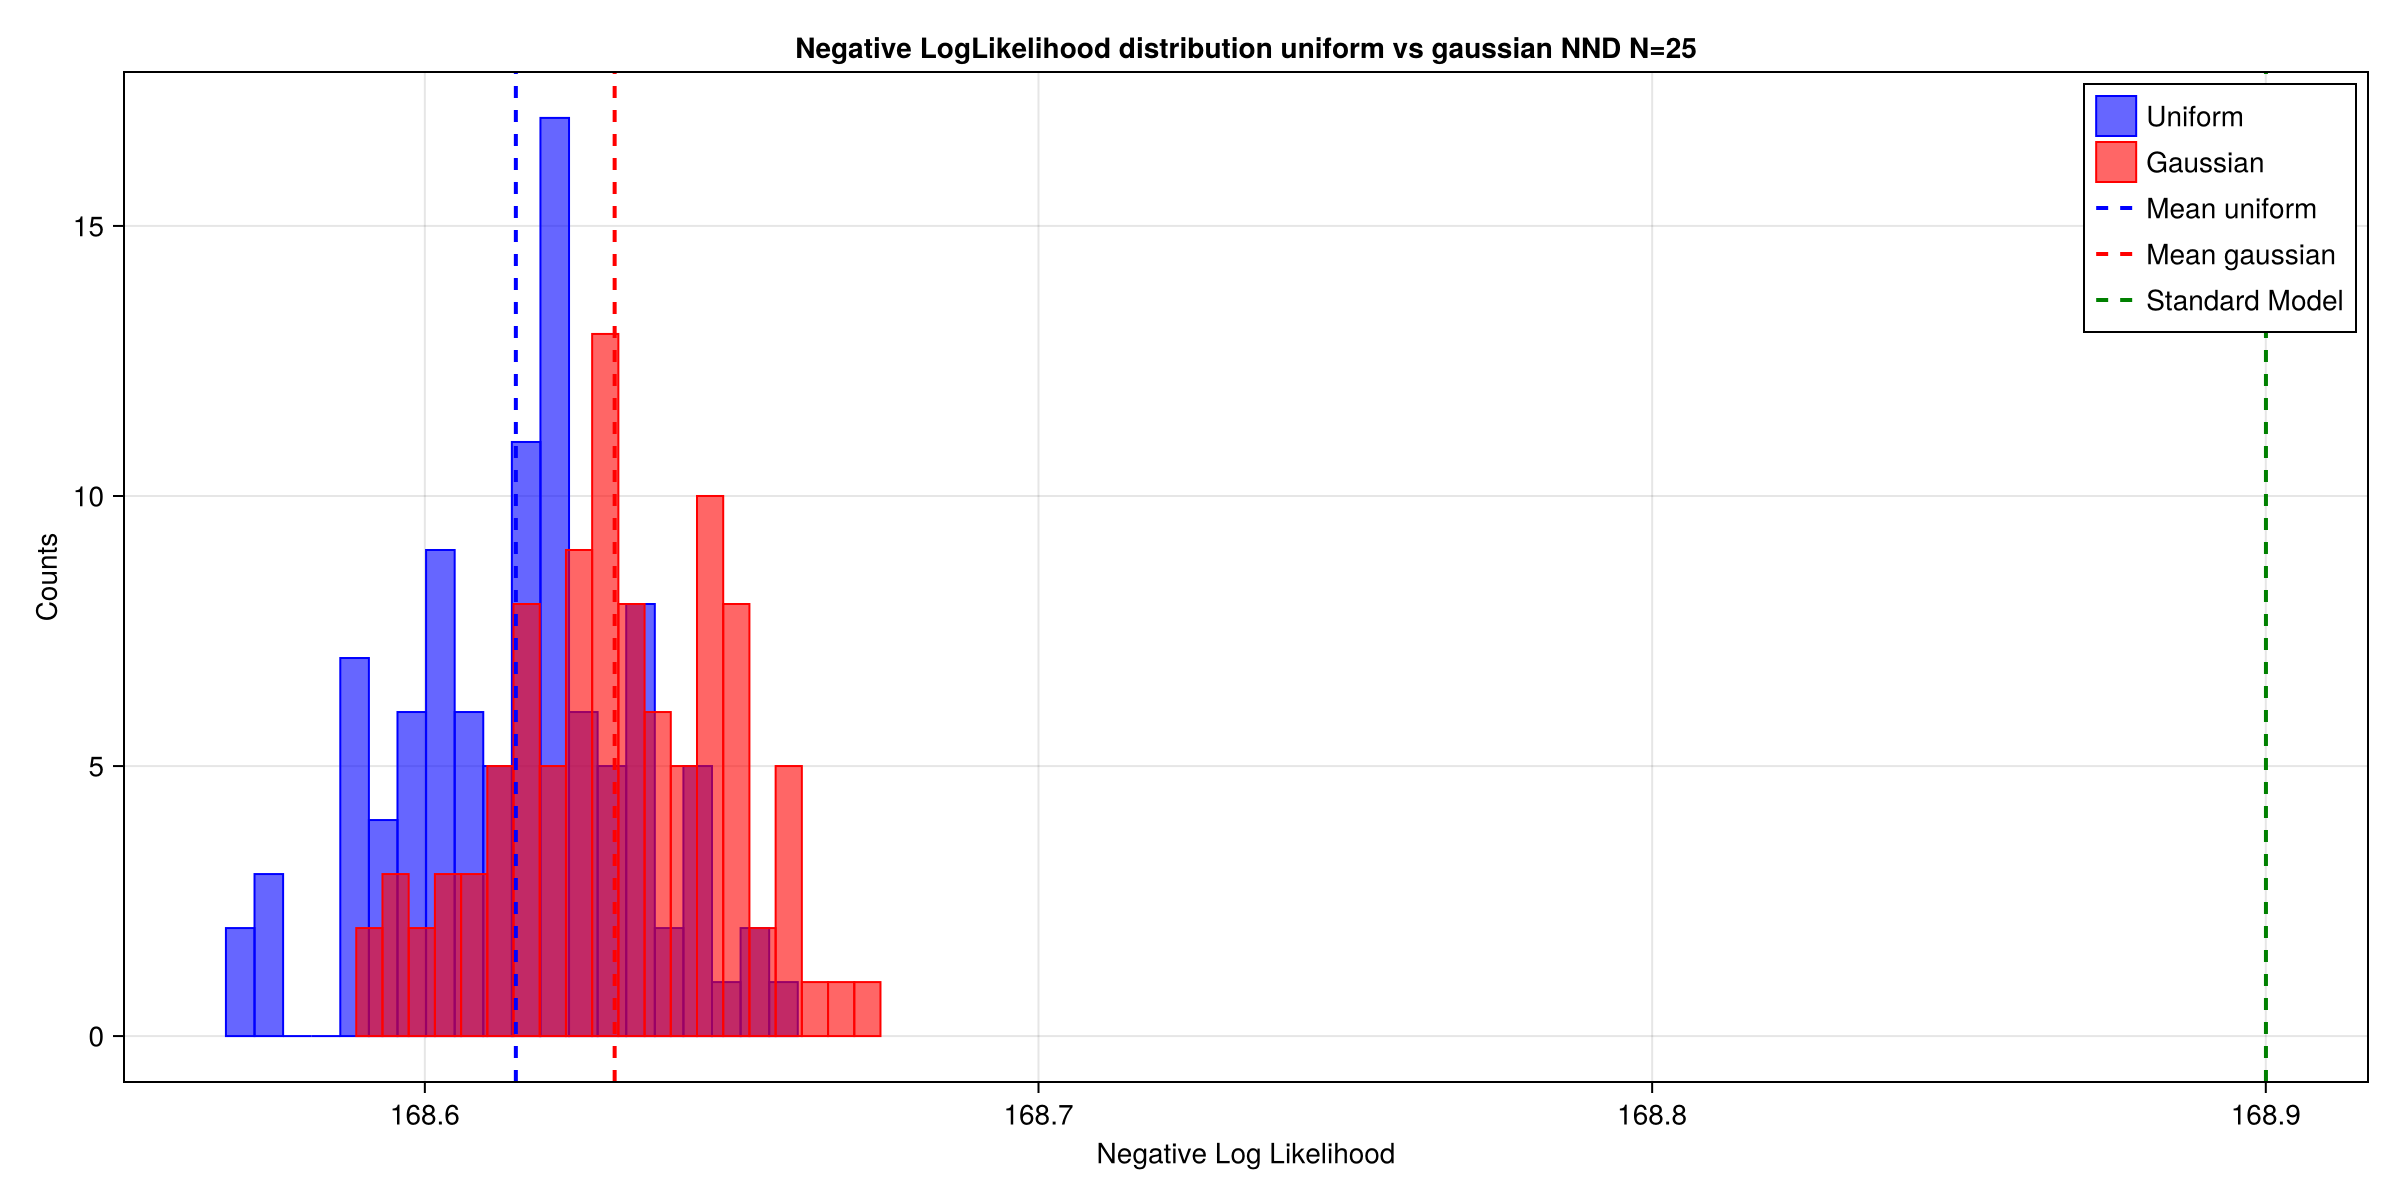

CairoMakie.Screen{IMAGE}


In [29]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = " Negative Log Likelihood ",
    ylabel = "Counts", 
    title = "Negative LogLikelihood distribution uniform vs gaussian NND N=25")

hist!(ax, trial[1], bins = 20, color = (:blue, 0.6), strokewidth = 1, strokecolor = :blue, label = "Uniform")
hist!(ax, trial[2], bins = 20, color = (:red, 0.6), strokewidth = 1, strokecolor = :red, label = "Gaussian")



vlines!(ax, [mean_un], color = :blue, linestyle = :dash, linewidth = 2, label = "Mean uniform")
vlines!(ax, [mean_norm], color = :red, linestyle = :dash, linewidth = 2, label = "Mean gaussian")
vlines!(ax, likelihood_SM, color = :green, linestyle = :dash, linewidth = 2, label = "Standard Model")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/dayabay_nll_NNM_N25_m0=0.01.png", fig)

In [30]:
function lik_ratio(N)

    ratios_un = Float64[]
    ratios_norm = Float64[]

    pvalue_un = Float64[]
    pvalue_norm = Float64[]

    likelihood_SM=-Newtrinos.logdensityof(Newtrinos.dayabay.get_forward_model(physics_SM, assets)(p_SM), assets.observed)

   
    @showprogress for i in 20:N
       trial=random_sampling(physics, experiments, p, i)
       mean_un= mean(trial[1])
       mean_norm= mean(trial[2])
       ratio_a= (likelihood_SM-mean_un) # test SM (H0) vs uniform (H1)
       ratios_b= (mean_un-mean_norm) # test uniform (H0) vs gaussian (H1)

       push!(ratios_un, ratio_a)
       push!(ratios_norm, ratios_b)

       df_SM = 2
       df_r=1   # Difference in number of parameters

       p_value_a = 1 - cdf(Chisq(df_SM), ratio_a)
       p_value_b = 1 - cdf(Chisq(df_r), ratios_b)

        push!(pvalue_un, p_value_a)
        push!(pvalue_norm, p_value_b)

    end

     
    
    return ratios_un, ratios_norm, pvalue_un, pvalue_norm
end

lik_ratio (generic function with 1 method)

In [31]:
likelihood_ratios= lik_ratio(25)

Progress:  10%|████▏                                    |  ETA: 2:44:06

LoadError: InterruptException:

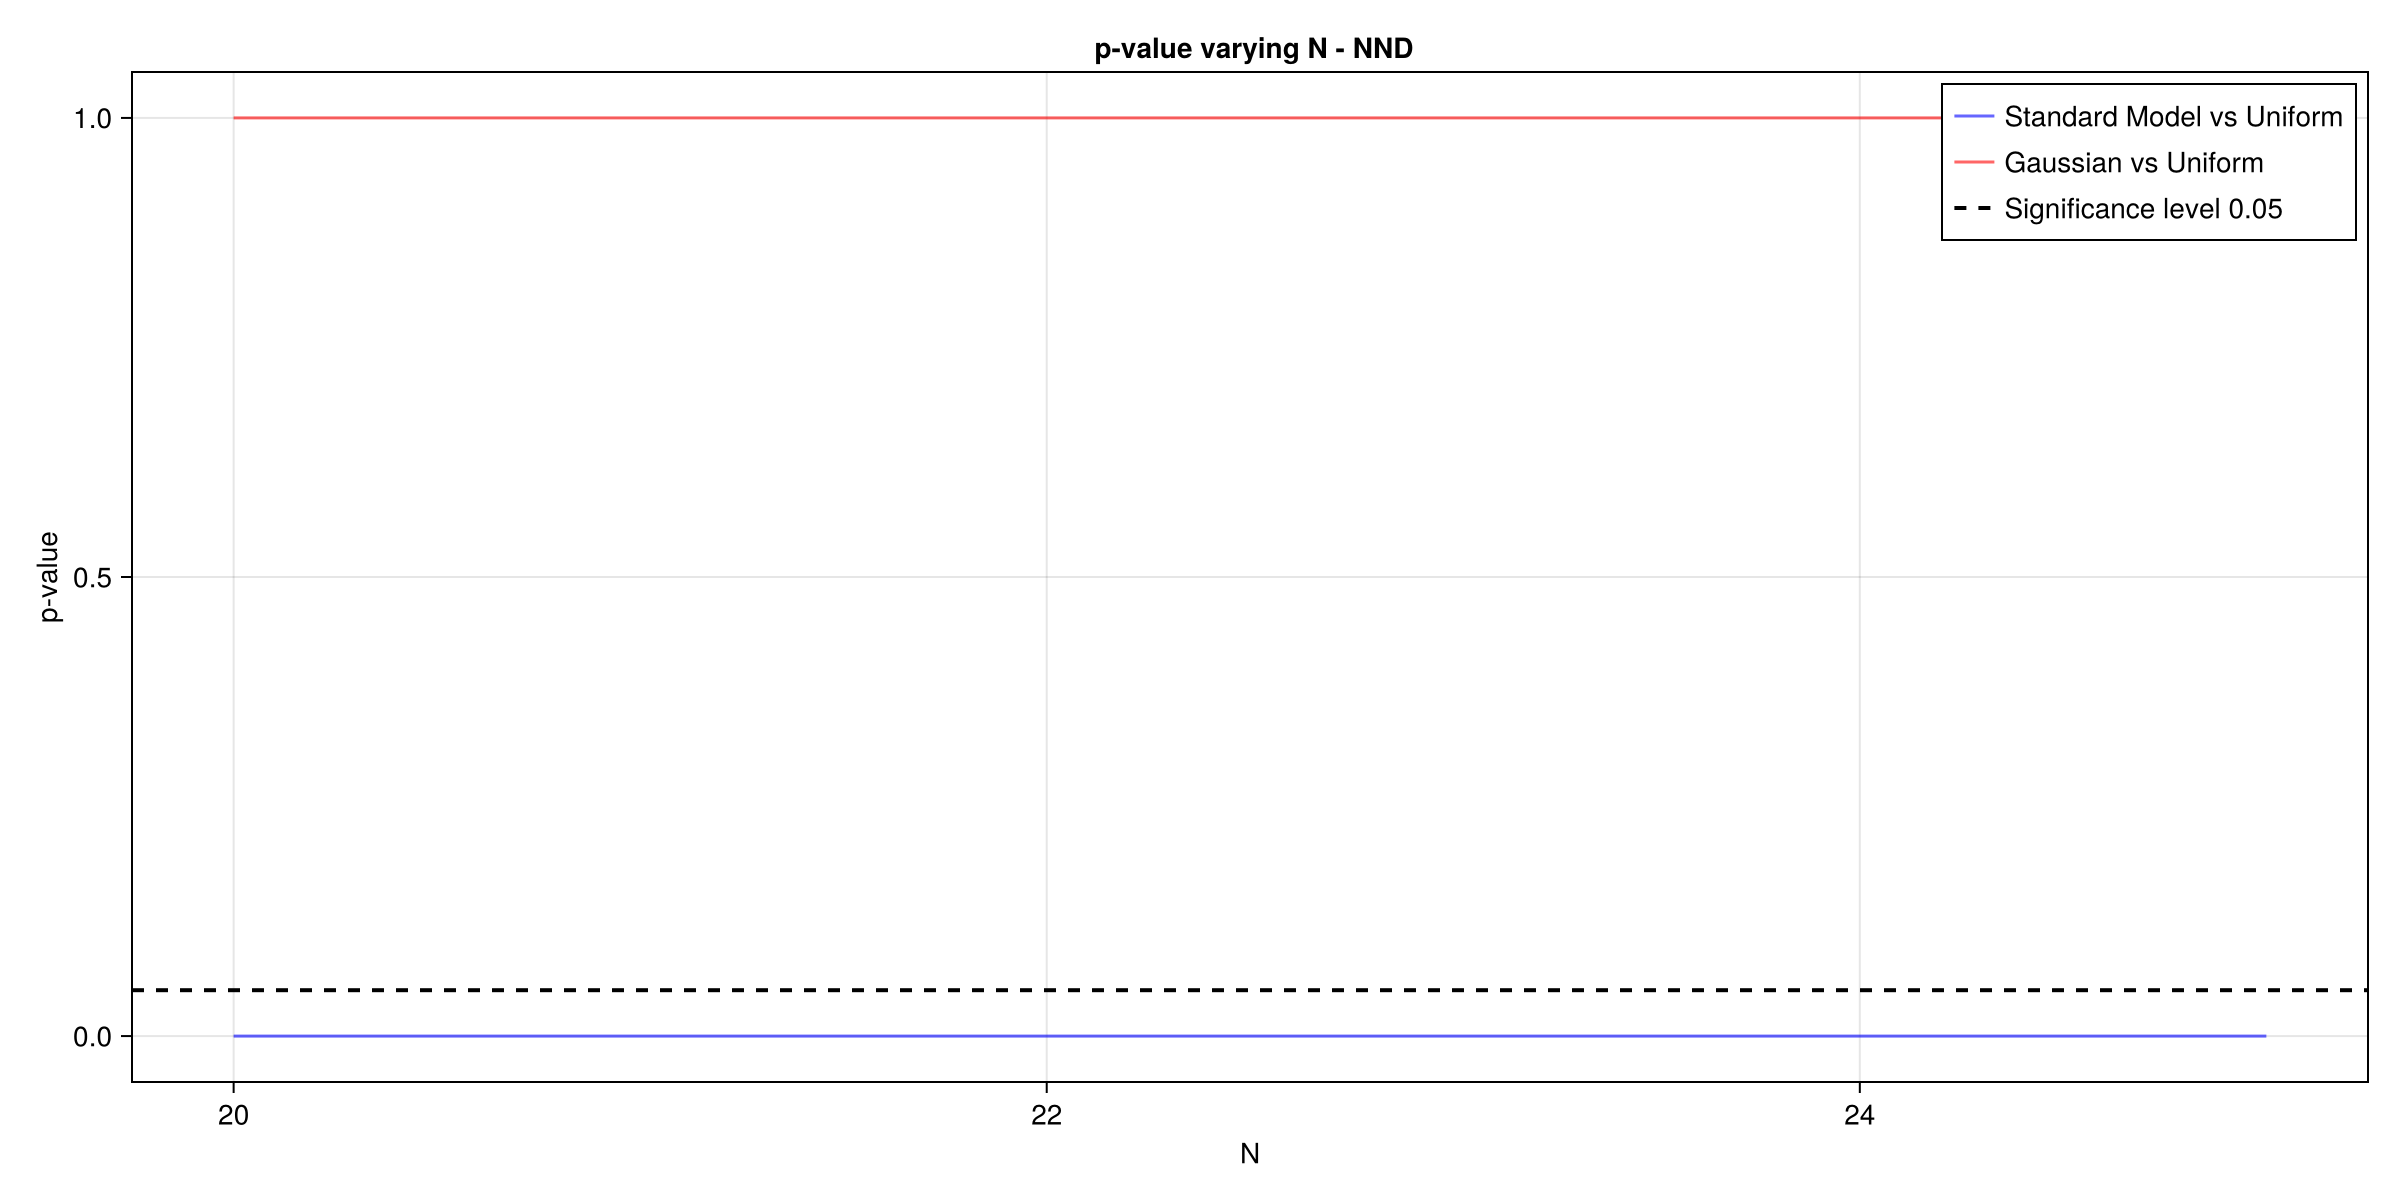

CairoMakie.Screen{IMAGE}


In [ ]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = " N ",
    ylabel = "p-value", 
    title = " p-value varying N - NND")

x=20:25
lines!(x, likelihood_ratios[:][3], color = (:blue, 0.6),  label = "Standard Model vs Uniform")
lines!(x, likelihood_ratios[:][4], color = (:red, 0.6),  label = "Gaussian vs Uniform")

hlines!(0.05, color = :black, linestyle = :dash, linewidth = 2, label = "Significance level 0.05")
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

display(fig)


#save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/dayabay_nll_NNM_r=1_pvalue.png", fig)